In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil
from pathlib import Path
import json
import subprocess

import thetaflow as thf
# import modelnn2 as thf
print("Thetaflow version: {}".format(thf.__version__))

import mpscr_models as mpscr
import pwexp
import gndr_utils as utils
import mps

I0000 00:00:1783682697.841903   28536 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783682699.151882   28536 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Thetaflow version: 0.0.35


/home/natan/.pyenv/versions/3.10.16/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
a0 = 1.0
p_min = 0.0
p_max = 1.0
B = 501

def log_a(m, q):
    return -tf.math.lgamma(m+1)

def a(m, q):
    return tf.math.exp( log_a(m, q) )

# For the Poisson, a0 is always equal to 1.0, as there is no second parameter, q
def a0(q):
    return 1.0

def phi(theta, q):
    return tf.identity(theta)

def log_phi(theta, q):
    return tf.math.log(theta)
                       
def phi_inv(u, q):
    return tf.identity(u)

def C(theta, q):
    return tf.math.exp(theta)

def C_inv(u, q):
    return tf.math.log(u)

def A(u, q):
    theta = phi_inv(u, q)
    return C(theta, q)

def sup(q):
    return tf.cast( np.arange(B), tf.float32 )

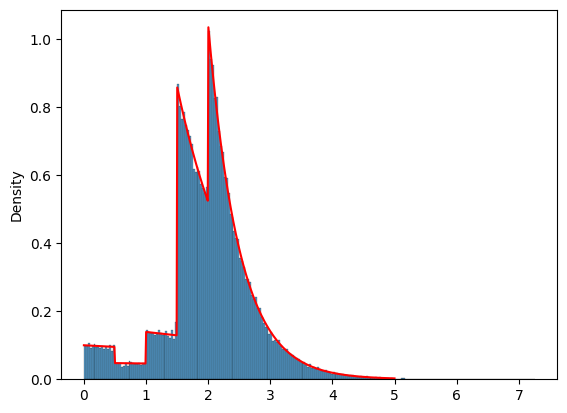

In [3]:
alpha = np.array([0.1, 0.05, 0.15, 1, 2])
s = np.array([0,0.5,1,1.5,2])
t = np.linspace(0.001, 5, 500)

h_t = pwexp.h(t, alpha, s)
H_t = pwexp.ch(t, alpha, s)
F_t = pwexp.cdf(t, alpha, s, lower_tail = True)
f_t = pwexp.pdf(t, alpha, s)
F_inv_t = pwexp.ppf(F_t, alpha, s)

sample_t = pwexp.rvs(alpha, s, size = 100000)

sns.histplot(x = sample_t, stat = "density")
plt.plot(t, f_t, color = "red")
# plt.plot(t, F_t)
# plt.plot(F_t, F_inv_t)
# plt.plot([0,np.max(t)], [0, np.max(t)])
plt.show()

To validate the implementation of our general model, we consider a simple data generating scheme with a single predictor variable, $x$.

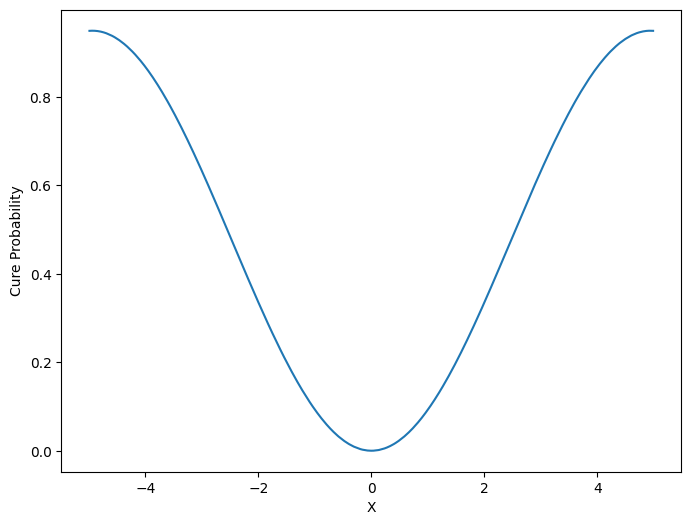

In [4]:
n = 500

x = np.random.uniform(size = n, low = -5.0, high = 5.0)

p_true = np.sin(x / np.pi)**2 * 0.95

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))
sns.lineplot(x = x, y = p_true, ax = ax)
ax.set_xlabel("X")
ax.set_ylabel("Cure Probability")
plt.show()

We consider the latent variables to follow a Poisson distribution merged with a standard Exp(1) distribution as a base distribution, $S_0$.

In [5]:
np.random.seed(10)
np.random.seed(1)

n_train = 400
n_test = 100

x_train = np.random.uniform(size = n_train, low = -5.0, high = 5.0)
x_test = np.random.uniform(size = n_test, low = -5.0, high = 5.0)

p_true_train = np.sin(x_train / np.pi)**2 * 0.95
p_true_test = np.sin(x_test / np.pi)**2 * 0.95

# theta = C^{-1}( a0 / p )
# For the Poisson, we have C(theta) = e^theta, a0 = 1.0
theta_train = np.log( 1.0 / p_true_train )
theta_test = np.log( 1.0 / p_true_test )
q = 0.0

# m = np.random.poisson(size = n, lam = theta)
m_train = mps.rvs(log_a, log_phi, theta_train, q, sup(q)).numpy()
m_test = mps.rvs(log_a, log_phi, theta_test, q, sup(q)).numpy()
cured_train = (m_train == 0).astype("int")
cured_test = (m_test == 0).astype("int")

# Random uniform generators for the true lifetimes
u_train = np.random.uniform(size = np.sum(m_train > 0) )
u_test = np.random.uniform(size = np.sum(m_test > 0) )
# True lifetimes
y_true_train = np.repeat(np.inf, n_train)
y_true_test = np.repeat(np.inf, n_test)

y_true_train[m_train > 0] = -np.log(1 - u_train**(1/m_train[m_train > 0])) / theta_train[m_train > 0]
y_true_test[m_test > 0] = -np.log(1 - u_test**(1/m_test[m_test > 0])) / theta_test[m_test > 0]

y_censor_train = np.random.uniform(size = n_train, low = 0.0, high = 5.0)
y_censor_test = np.random.uniform(size = n_test, low = 0.0, high = 5.0)

y_train = y_true_train.copy()
y_test = y_true_test.copy()

delta_train = np.repeat(0, n_train)
delta_test = np.repeat(0, n_test)

# Define observed lifetimes as 1
delta_train[y_true_train <= y_censor_train] = 1
delta_test[y_true_test <= y_censor_test] = 1

# Censor lifetimes greater than censorship times
y_train[y_true_train > y_censor_train] = y_censor_train[y_true_train > y_censor_train]
y_test[y_true_test > y_censor_test] = y_censor_test[y_true_test > y_censor_test]

print("Proportion of censored (Train): {:.2f}%".format( (1-np.mean(delta_train))*100 ))
print("Proportion of censored (Test): {:.2f}%".format( (1-np.mean(delta_test))*100 ))

Proportion of censored (Train): 60.50%
Proportion of censored (Test): 65.00%


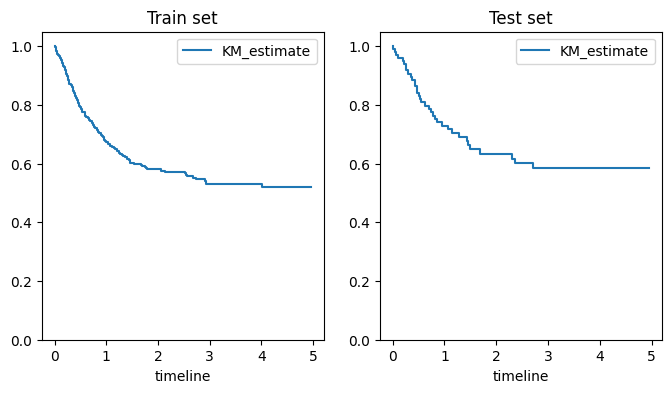

In [6]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,4))

km = lifelines.KaplanMeierFitter()
km.fit(y_train, delta_train)
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)
ax[0].set_title("Train set")

km = lifelines.KaplanMeierFitter()
km.fit(y_test, delta_test)
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)
ax[1].set_title("Test set")


plt.show()

In [7]:
def fit_model(dist,
              x_train, y_train, delta_train,
              x_test, y_test, delta_test,
              fixed_q = 0.0,
              finetune = True, seed = 10):
    '''
        Receives the name of a particular subfamily inside the two-parameter MPS family, fit the associated model
        and return all relevant results for this study.
    '''

    dist = dist.lower()
    if(dist == "poisson"):
        model_spec = mpscr.MPSPoisson()
    elif(dist == "bin" or dist == "binomial"):
        model_spec = mpscr.MPSBinomial(fixed_q)
    elif(dist == "negbin"):
        model_spec = mpscr.MPSNegBinomial()
    elif(dist == "geometric"):
        model_spec = mpscr.MPSNegBinomial(1.0)
    elif(dist == "log" or dist == "logarithmic"):
        model_spec = mpscr.MPSLogarithmic()
    elif(dist == "rgp"):
        model_spec = mpscr.MPSRGP()
    else:
        raise Exception("Please, provide a valid subfamily name.")

    data_train = [y_train, delta_train]
    data_test = [y_test, delta_test]
    
    with tf.device("/CPU:0"):
        model = mpscr.build_mpscr_model(y_train, delta_train, (1,), model_spec, seed = seed, n_cuts = 5)
        model.pre_train_model(epochs = None, x = x_train[:,None], data = data_train, shuffle = True)
        model.train_model(epochs = 5000, x = x_train[:,None], data = data_train,
                                  shuffle = True,
                                  get_covariances = False,
                                  validation = True, val_prop = 0.2, force_training_validation = False,
                                  optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                                  optimizer_nn = optimizers.Adam(learning_rate = 0.01),
                                  fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                  early_stopping = True, early_stopping_patience = 50,
                                  early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                                  reduce_lr = True, reduce_lr_warmup = 0,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                                  reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                  fine_tune = finetune,
                                  finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                                  finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                                  finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                  finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                                  finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                  deterministic = True,
                                  verbose = True, print_freq = 1)

    results_cure_model = model.get_survival_cure(y_train, x_train[:,None], y_test, x_test[:,None], ngrid = 100)
    return model, results_cure_model

### Testing Log

In [8]:
model_log_spec = mpscr.MPSLogarithmic()

log_model, results_cure_log = fit_model("log", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5, finetune = False)
results_cure_log["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_log["S_train"], delta_train)
results_cure_log["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_log["S_test"], delta_test)

Global seed set to 10.
Initializing training...
loglik NAN:.. Epoch: [ 43 / 5000 ]  | Avg. Train NLL:  0.727998912 | Avg. Validation NLL:  0.617815673 | Best Avg. Validation NLL:  0.617815673 | Speed:  0.00466468744  epoch/s    | Elapsed Time:  0.200581551  s    
Aprime_u[nan] [-0.0576171875]
loglik NAN:.. Epoch: [ 44 / 5000 ]  | Avg. Train NLL:  nan | Avg. Validation NLL:  0.616465688 | Best Avg. Validation NLL:  0.616465688 | Speed:  0.00493862946  epoch/s    | Elapsed Time:  0.2172997  s   
Aprime_u[nan] [-0.0576171875]
loglik NAN:
Aprime_u[nan] [-0.9140625]
loglik NAN:.. Epoch: [ 45 / 5000 ]  | Avg. Train NLL:  0.726143301 | Avg. Validation NLL:  nan | Best Avg. Validation NLL:  0.616465688 | Speed:  0.00524789514  epoch/s    | Elapsed Time:  0.236155272  s   
Aprime_u[nan] [-0.385742188 -0.15234375 -0.165039062]
loglik NAN:
Aprime_u[nan] [-0.383789062]
loglik NAN:.. Epoch: [ 46 / 5000 ]  | Avg. Train NLL:  nan | Avg. Validation NLL:  nan | Best Avg. Validation NLL:  0.616465688 | 

In [11]:
y_train[:20]

array([0.0522466 , 0.68547704, 0.10376341, 0.15458487, 0.23340159,
       0.49213903, 4.54224053, 3.57187576, 2.40950009, 3.53694945,
       1.21302942, 0.12469723, 4.01537036, 0.56983745, 1.93534676,
       0.24736351, 1.18178418, 0.0381345 , 2.94391165, 0.08674713])

In [8]:
model_log_spec = mpscr.MPSLogarithmic()

log_model, results_cure_log = fit_model("log", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5, finetune = False)
results_cure_log["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_log["S_train"], delta_train)
results_cure_log["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_log["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 555 / 5000 ]  | Avg. Train NLL:  0.539897501 | Avg. Validation NLL:  0.520302594 | Best Avg. Validation NLL:  0.517130315 | Speed:  0.0121424086  epoch/s    | Elapsed Time:  6.73903704  s     
Convergence criterion reached. Stopping.
Restoring best weights...6 / 5000 ]  | Avg. Train NLL:  0.539895535 | Avg. Validation NLL:  0.520610034 | Best Avg. Validation NLL:  0.517130315 | Speed:  0.0121389618  epoch/s    | Elapsed Time:  6.74926281  s   

Done.
Optimization finished in 12.602 seconds.


In [8]:
poisson_model, results_cure_poisson = fit_model("poisson", x_train, y_train, delta_train, x_test, y_test, delta_test)
results_cure_poisson["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_train"], delta_train)
results_cure_poisson["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 273 / 5000 ]  | Avg. Train NLL:  0.510056198 | Avg. Validation NLL:  0.641679585 | Best Avg. Validation NLL:  0.641201198 | Speed:  0.0033522544  epoch/s    | Elapsed Time:  0.915165424  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 58 / 5000 ]  | Avg. Train NLL:  0.51074338 | Best Avg. Train NLL:  0.51074338 | Avg. Validation NLL:  0.639681041 | Speed:  0.00298312609  epoch/s    | Elapsed Time:  0.173021317  s      
Convergence criterion reached. Stopping.
Restoring best weights... / 5000 ]  | Avg. Train NLL:  0.510740221 | Best Avg. Train NLL:  0.510740221 | Avg. Validation NLL:  0.639680386 | Speed:  0.00297375862  epoch/s    | Elapsed Time:  0.175451756  s   

Done.
Optimization finished in 7.785 seconds.


In [9]:
model_log_spec = mpscr.MPSLogarithmic()

log_model, results_cure_log = fit_model("log", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5, finetune = False)
results_cure_log["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_log["S_train"], delta_train)
results_cure_log["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_log["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 388 / 5000 ]  | Avg. Train NLL:  nan | Avg. Validation NLL:  0.726519227 | Best Avg. Validation NLL:  0.726170361 | Speed:  0.0120750098  epoch/s    | Elapsed Time:  4.68510389  s    s        
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 6.863 seconds.


### Poisson

In [9]:
data_train = [y_train, delta_train]
data_test = [y_test, delta_test]

poisson_spec = mpscr.MPSPoisson()
with tf.device("/CPU:0"):
    poisson_model = mpscr.build_mpscr_model(y_train, delta_train, (1,), poisson_spec, seed = 10, n_cuts = 5)
    poisson_model.pre_train_model(epochs = None, x = x_train[:,None], data = data_train, shuffle = True)
    poisson_model.train_model(epochs = 5000, x = x_train[:,None], data = data_train,
                              shuffle = True,
                              get_covariances = False,
                              validation = True, val_prop = 0.2, force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 0.01),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 101 / 5000 ]  | Avg. Train NLL:  0.540355802 | Avg. Validation NLL:  0.547040641 | Best Avg. Validation NLL:  0.542696118 | Speed:  0.0025473726  epoch/s    | Elapsed Time:  0.257284641  s    
Convergence criterion reached. Stopping.
Restoring best weights...2 / 5000 ]  | Avg. Train NLL:  0.540195465 | Avg. Validation NLL:  0.547161 | Best Avg. Validation NLL:  0.542696118 | Speed:  0.00254548527  epoch/s    | Elapsed Time:  0.259639502  s   

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 206 / 5000 ]  | Avg. Train NLL:  0.526193321 | Best Avg. Train NLL:  0.526193321 | Avg. Validation NLL:  0.579854727 | Speed:  0.00196753186  epoch/s    | Elapsed Time:  0.405311584  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 7.620 seconds.


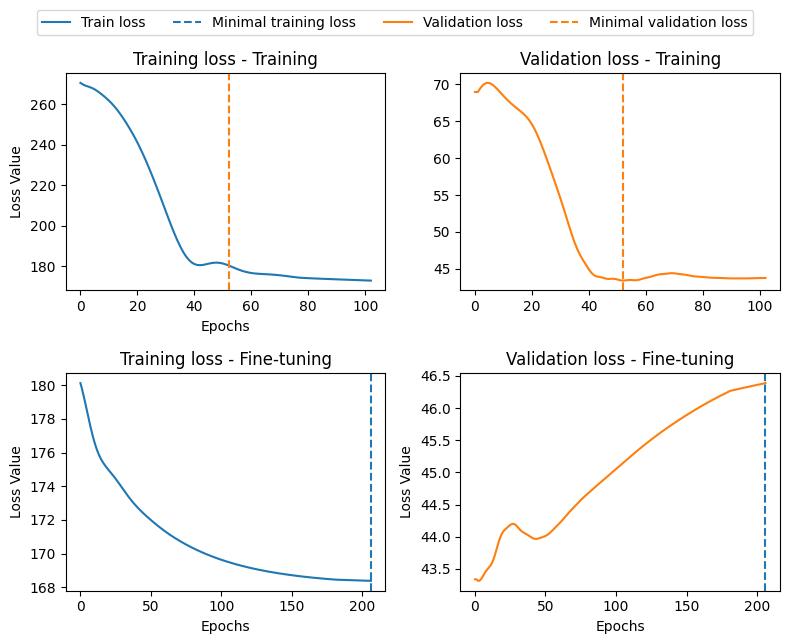

In [10]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (8,6))

utils.plot_model_convergence( poisson_model, ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[1,0], ax4 = ax[1,1] )

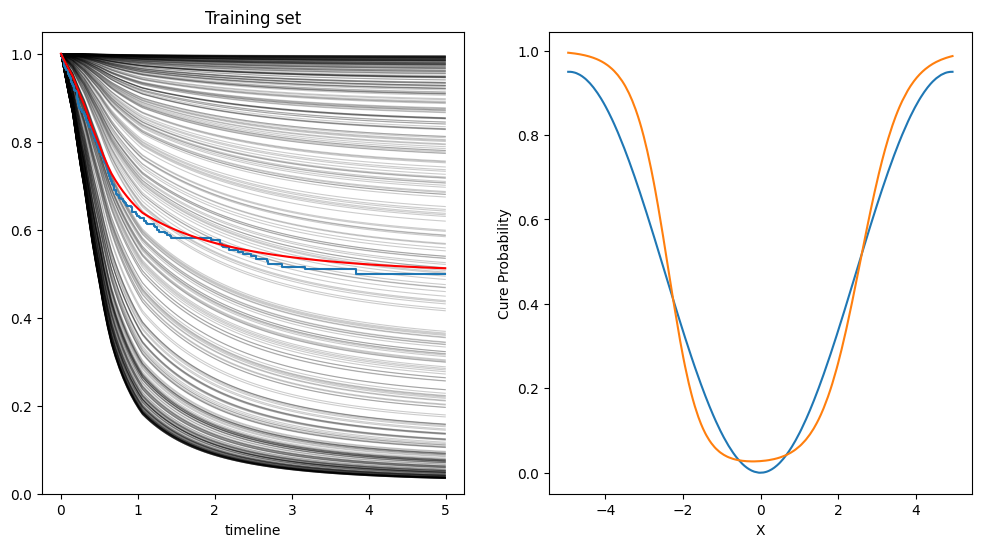

In [11]:
results_cure_poisson = poisson_model.get_survival_cure(y_train, x_train[:,None], y_test, x_test[:,None], ngrid = 100)

t = np.linspace(0.0001, np.max(np.concatenate([y_train, y_test])), 100)[:, None]

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

utils.average_kaplan_meier(results_cure_poisson["ts_grid"], results_cure_poisson["S_ts_train"],
                           y_train, delta_train, show_individual = True, ax = ax[0])
ax[0].get_legend().remove()

sns.lineplot(x = x_train, y = p_true_train, ax = ax[1])
sns.lineplot(x = x_train, y = results_cure_poisson["p_train"], ax = ax[1])
ax[1].set_xlabel("X")
ax[1].set_ylabel("Cure Probability")

plt.show()

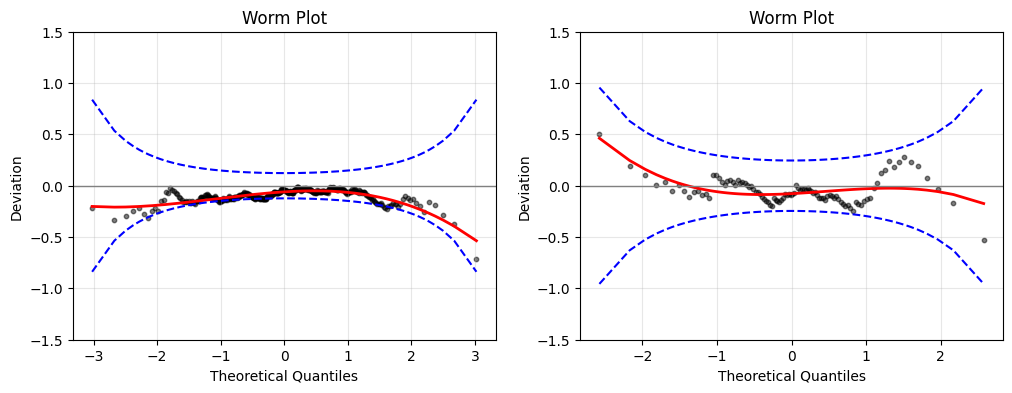

In [12]:
resid_train_poisson = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_train"], delta_train)
resid_test_poisson = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_test"], delta_test)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

utils.plot_worm( resid_train_poisson, ax = ax[0] )
utils.plot_worm( resid_test_poisson, ax = ax[1] )

# Fitting multiple models from the MPS

As shown above, the overall framework for the model is finished. Now, we are naturally interested in studying the behaviour of this model under misspecification. In particular, for this dataset, we considered the Poisson distribution as the generating process. Of all candidate models we can think in the MPS family, can we select the Poisson distributio as the winning model?

To do that, we incorporate the entire analysis from above into a single function, so we can obtain all the results for comparison using a single call.

In [13]:
def fit_model(dist,
              x_train, y_train, delta_train,
              x_test, y_test, delta_test,
              fixed_q = 0.0,
              finetune = True):
    '''
        Receives the name of a particular subfamily inside the two-parameter MPS family, fit the associated model
        and return all relevant results for this study.
    '''

    dist = dist.lower()
    if(dist == "poisson"):
        model_spec = mpscr.MPSPoisson()
    elif(dist == "bin" or dist == "binomial"):
        model_spec = mpscr.MPSBinomial(fixed_q)
    elif(dist == "negbin"):
        model_spec = mpscr.MPSNegBinomial()
    elif(dist == "geometric"):
        model_spec = mpscr.MPSNegBinomial(1.0)
    elif(dist == "log" or dist == "logarithmic"):
        model_spec = mpscr.MPSLogarithmic()
    elif(dist == "rgp"):
        model_spec = mpscr.MPSRGP()
    else:
        raise Exception("Please, provide a valid subfamily name.")

    data_train = [y_train, delta_train]
    data_test = [y_test, delta_test]
    
    with tf.device("/CPU:0"):
        model = mpscr.build_mpscr_model(y_train, delta_train, (1,), model_spec, seed = 10, n_cuts = 5)
        model.pre_train_model(epochs = None, x = x_train[:,None], data = data_train, shuffle = True)
        model.train_model(epochs = 5000, x = x_train[:,None], data = data_train,
                                  shuffle = True,
                                  get_covariances = False,
                                  validation = True, val_prop = 0.2, force_training_validation = False,
                                  optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                                  optimizer_nn = optimizers.Adam(learning_rate = 0.01),
                                  fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                  early_stopping = True, early_stopping_patience = 50,
                                  early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                                  reduce_lr = True, reduce_lr_warmup = 0,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                                  reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                  fine_tune = finetune,
                                  finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                                  finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                                  finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                  finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                                  finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                  deterministic = True,
                                  verbose = True, print_freq = 1)

    results_cure_model = model.get_survival_cure(y_train, x_train[:,None], y_test, x_test[:,None], ngrid = 100)
    return model, results_cure_model

In [14]:
poisson_model, results_cure_poisson = fit_model("poisson", x_train, y_train, delta_train, x_test, y_test, delta_test)
results_cure_poisson["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_train"], delta_train)
results_cure_poisson["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 101 / 5000 ]  | Avg. Train NLL:  0.540355802 | Avg. Validation NLL:  0.547040641 | Best Avg. Validation NLL:  0.542696118 | Speed:  0.00279913796  epoch/s    | Elapsed Time:  0.282712936  s   
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 102 / 5000 ]  | Avg. Train NLL:  0.540195465 | Avg. Validation NLL:  0.547161 | Best Avg. Validation NLL:  0.542696118 | Speed:  0.0027933612  epoch/s    | Elapsed Time:  0.284922838  s   Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 206 / 5000 ]  | Avg. Train NLL:  0.526193321 | Best Avg. Train NLL:  0.526193321 | Avg. Validation NLL:  0.579854727 | Speed:  0.00285467366  epoch/s    | Elapsed Time:  0.588062763  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 3.813 seconds.


### Binomial

In [15]:
bin5_model, results_cure_bin5 = fit_model("bin", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5)
results_cure_bin5["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_bin5["S_train"], delta_train)
results_cure_bin5["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_bin5["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 106 / 5000 ]  | Avg. Train NLL:  0.532954395 | Avg. Validation NLL:  0.559815109 | Best Avg. Validation NLL:  0.548650742 | Speed:  0.00290599419  epoch/s    | Elapsed Time:  0.308035374  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 160 / 5000 ]  | Avg. Train NLL:  0.526670873 | Best Avg. Train NLL:  0.526670873 | Avg. Validation NLL:  0.589574933 | Speed:  0.00350767514  epoch/s    | Elapsed Time:  0.561228037  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 4.517 seconds.


### Negative Binomial (Mean-Variance parametrization)

In [16]:
nb_model, results_cure_nb = fit_model("negbin", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5)
results_cure_nb["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_nb["S_train"], delta_train)
results_cure_nb["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_nb["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 161 / 5000 ]  | Avg. Train NLL:  0.537466884 | Avg. Validation NLL:  0.543250203 | Best Avg. Validation NLL:  0.539897382 | Speed:  0.00332925771  epoch/s    | Elapsed Time:  0.536010504  s   
Convergence criterion reached. Stopping.
Restoring best weights...2 / 5000 ]  | Avg. Train NLL:  0.537334859 | Avg. Validation NLL:  0.543321133 | Best Avg. Validation NLL:  0.539897382 | Speed:  0.0033324  epoch/s    | Elapsed Time:  0.539848804  s   

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 200 / 5000 ]  | Avg. Train NLL:  0.52652353 | Best Avg. Train NLL:  0.52652353 | Avg. Validation NLL:  0.571594238 | Speed:  0.00208740239  epoch/s    | Elapsed Time:  0.417480469  s     
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 4.534 seconds.


### Geometric

In [17]:
geometric_model, results_cure_geometric = fit_model("geometric", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5)
results_cure_geometric["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_geometric["S_train"], delta_train)
results_cure_geometric["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_geometric["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 206 / 5000 ]  | Avg. Train NLL:  0.550990164 | Avg. Validation NLL:  0.550828516 | Best Avg. Validation NLL:  0.549965 | Speed:  0.00381877576  epoch/s    | Elapsed Time:  0.786667824  s      
Convergence criterion reached. Stopping.
Restoring best weights...7 / 5000 ]  | Avg. Train NLL:  0.550897241 | Avg. Validation NLL:  0.550855517 | Best Avg. Validation NLL:  0.549965 | Speed:  0.00381372636  epoch/s    | Elapsed Time:  0.789441347  s   

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 242 / 5000 ]  | Avg. Train NLL:  0.537360668 | Best Avg. Train NLL:  0.537360668 | Avg. Validation NLL:  0.565651238 | Speed:  0.00266363216  epoch/s    | Elapsed Time:  0.644598961  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 4.623 seconds.


### Logarithmic

In [18]:
model_log_spec = mpscr.MPSLogarithmic()

log_model, results_cure_log = fit_model("log", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5, finetune = False)
results_cure_log["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_log["S_train"], delta_train)
results_cure_log["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_log["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 241 / 5000 ]  | Avg. Train NLL:  nan | Avg. Validation NLL:  nan | Best Avg. Validation NLL:  0.601240873 | Speed:  0.0113263112  epoch/s    | Elapsed Time:  2.72964096  s   4  s   8  s       
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 242 / 5000 ]  | Avg. Train NLL:  nan | Avg. Validation NLL:  0.602639198 | Best Avg. Validation NLL:  0.601240873 | Speed:  0.0113202911  epoch/s    | Elapsed Time:  2.73951054  s   Restoring best weights...

Done.
Optimization finished in 4.532 seconds.


In [24]:
model_log_spec = mpscr.MPSLogarithmic()

In [1]:
# model_log_spec.C_inv( model_log_spec.a0(0.0) / results_cure_log["p_train"], 0.0 )

In [16]:
log_model, results_cure_log = fit_model("log", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5, finetune = False)
results_cure_log["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_log["S_train"], delta_train)
results_cure_log["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_log["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 158 / 5000 ]  | Avg. Train NLL:  nan | Avg. Validation NLL:  nan | Best Avg. Validation NLL:  0.684064686 | Speed:  0.00963035226  epoch/s    | Elapsed Time:  1.52159572  s    6  s   5  s     
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 3.682 seconds.


### RGP

In [17]:
rgp_model, results_cure_rgp = fit_model("rgp", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5)
results_cure_rgp["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_rgp["S_train"], delta_train)
results_cure_rgp["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_rgp["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 868 / 5000 ]  | Avg. Train NLL:  0.640742421 | Avg. Validation NLL:  0.497324079 | Best Avg. Validation NLL:  0.496414 | Speed:  0.0109398831  epoch/s    | Elapsed Time:  9.49581814  s        
Convergence criterion reached. Stopping.
Restoring best weights...9 / 5000 ]  | Avg. Train NLL:  0.64073205 | Avg. Validation NLL:  0.497341871 | Best Avg. Validation NLL:  0.496414 | Speed:  0.0109385513  epoch/s    | Elapsed Time:  9.50560188  s   

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 59 / 5000 ]  | Avg. Train NLL:  0.641271 | Best Avg. Train NLL:  0.641271 | Avg. Validation NLL:  0.498690516 | Speed:  0.0128968405  epoch/s    | Elapsed Time:  0.76091361  s   5  s     
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 13.955 seconds.


# Comparing all models

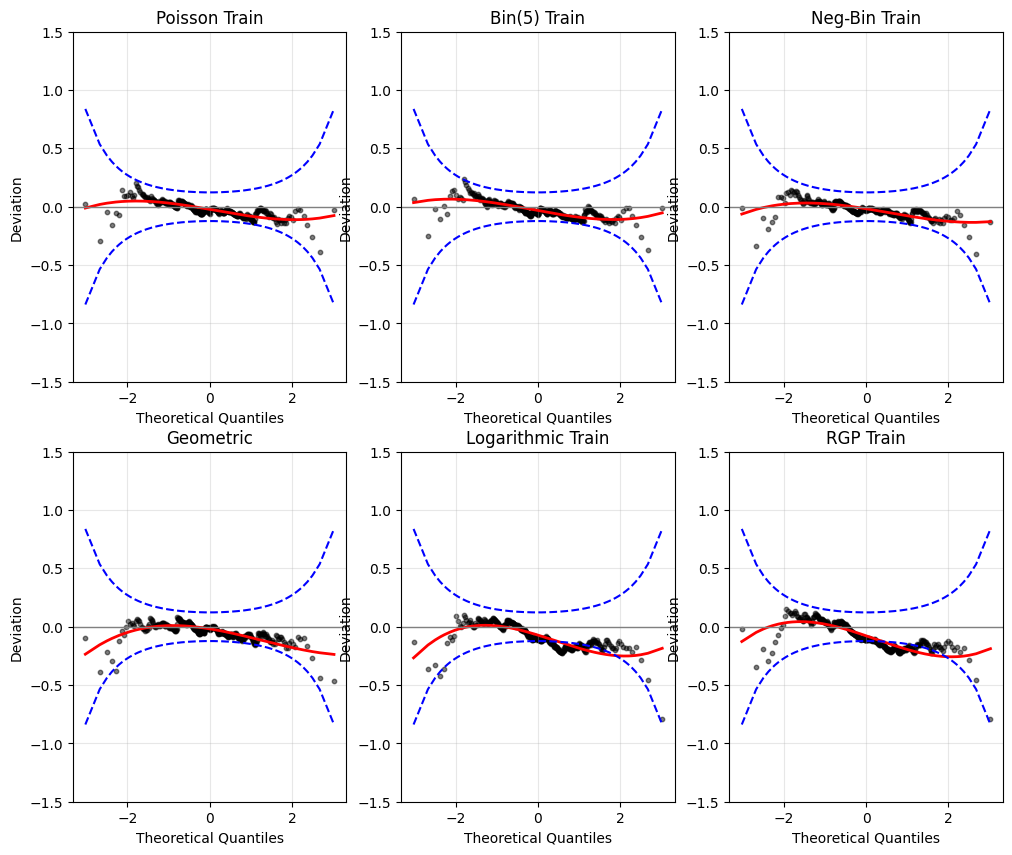

In [18]:
fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = (12,10))

utils.plot_worm( results_cure_poisson["resid_train"], ax = ax[0,0] )
ax[0,0].set_title("Poisson Train")
utils.plot_worm( results_cure_bin5["resid_train"], ax = ax[0,1] )
ax[0,1].set_title("Bin(5) Train")
utils.plot_worm( results_cure_nb["resid_train"], ax = ax[0,2] )
ax[0,2].set_title("Neg-Bin Train")
utils.plot_worm( results_cure_geometric["resid_train"], ax = ax[1,0] )
ax[1,0].set_title("Geometric")
utils.plot_worm( results_cure_log["resid_train"], ax = ax[1,1] )
ax[1,1].set_title("Logarithmic Train")
utils.plot_worm( results_cure_rgp["resid_train"], ax = ax[1,2] )
ax[1,2].set_title("RGP Train")
plt.show()

In [19]:
from scipy.stats import anderson

In [20]:
ad_poisson = anderson( results_cure_poisson["resid_test"] ).statistic
ad_bin5 = anderson( results_cure_bin5["resid_test"] ).statistic
ad_nb = anderson( results_cure_nb["resid_test"] ).statistic
ad_log = anderson( results_cure_log["resid_test"] ).statistic

pd.DataFrame({"Set": ["Test", "Test", "Test", "Test"],
              "Model": ["Poisson", "Bin5", "NegBin", "Logarithmic"],
              "ad_statistic": [ad_poisson, ad_bin5, ad_nb, ad_log]})

,Set,Model,ad_statistic
0,Test,Poisson,0.467239
1,Test,Bin5,0.476258
2,Test,NegBin,0.449624
3,Test,Logarithmic,1.191613
